# 🌈 The Gray Lie: Color Reproduction & Filters in B&W

### Welcome, Visual Scientists!
In the world of B&W photography, we are constantly translating a vibrant, multi-colored world into a simple scale of grays. But here is a secret: **B&W film does not see the world the way your eyes do.**

In this notebook, we will investigate how colors are represented by luminosity, why early film was "color blind," and how we can use colored glass (filters) to hack the laws of physics and create more dramatic images.

**Teacher Instructions:** Follow the iterations step-by-step to understand how to "see" in B&W.

## Iteration 1: The Luminosity Problem

Every color has two main properties that matter to us:
1. **Hue**: The "color" itself (Red, Green, Blue).
2. **Luminosity**: How bright or dark the color appears to be.

The problem? In B&W, two completely different hues can have the exact same luminosity. When this happens, they look identical in your photo, making the image look "flat" or "muddy."

Let's run the simulation below to see this in action.

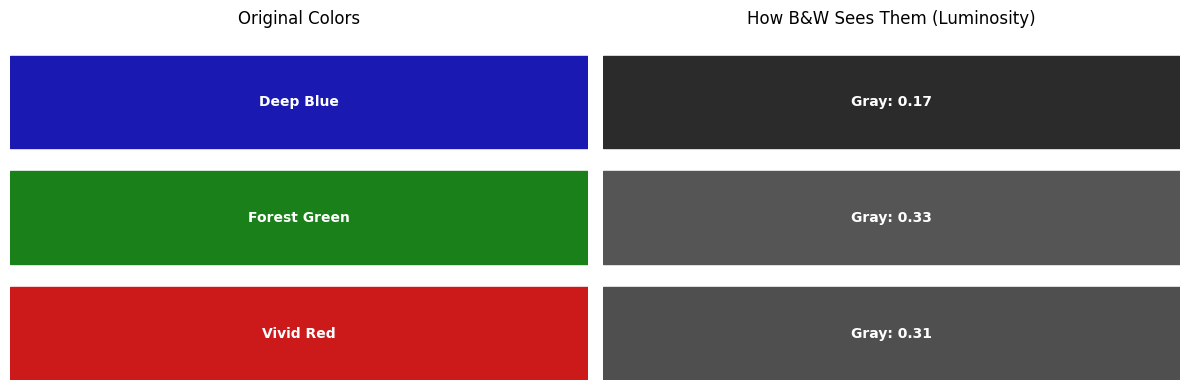

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def show_color_to_gray():
    # Define three colors with similar perceived luminosity
    # Red, Green, and Blue patches
    colors = {
        'Vivid Red': [0.8, 0.1, 0.1],
        'Forest Green': [0.1, 0.5, 0.1],
        'Deep Blue': [0.1, 0.1, 0.7]
    }
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    for i, (name, rgb) in enumerate(colors.items()):
        # Original Color
        ax[0].add_patch(plt.Rectangle((0, i), 1, 0.8, color=rgb))
        ax[0].text(0.5, i+0.4, name, color='white', ha='center', va='center', fontweight='bold')
        
        # Standard B&W Conversion (Luminosity formula: 0.299R + 0.587G + 0.114B)
        gray_val = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
        ax[1].add_patch(plt.Rectangle((0, i), 1, 0.8, color=[gray_val]*3))
        ax[1].text(0.5, i+0.4, f'Gray: {gray_val:.2f}', color='black' if gray_val > 0.5 else 'white', 
                   ha='center', va='center', fontweight='bold')

    ax[0].set_title("Original Colors")
    ax[1].set_title("How B&W Sees Them (Luminosity)")
    
    for a in ax:
        a.set_xlim(0, 1)
        a.set_ylim(0, len(colors))
        a.axis('off')

    plt.tight_layout()
    plt.show()

show_color_to_gray()

## Iteration 2: The Spectral Sensitivity (The "Blue Bias")

Silver halide crystals—the light-sensitive heart of film—are naturally sensitive to **Ultraviolet (UV)** and **Blue** light. They are actually "color blind" to everything else! 

Over 150 years, chemists developed ways to make film "see" more colors:

1. **Blue-Sensitive (1800s)**: Sees only UV and Blue. Reds and Greens look almost black. Skies look white (washed out).
2. **Orthochromatic (Late 1800s)**: Adds sensitivity to Green. Reds are still black. Great for skin tones in some cases, but "unnatural" for landscapes.
3. **Panchromatic (Early 1900s - Today)**: Sensitive to the full visible spectrum (Blue, Green, Red). This is what most B&W film is today.

Let's simulate how these different film types "see" a rainbow.

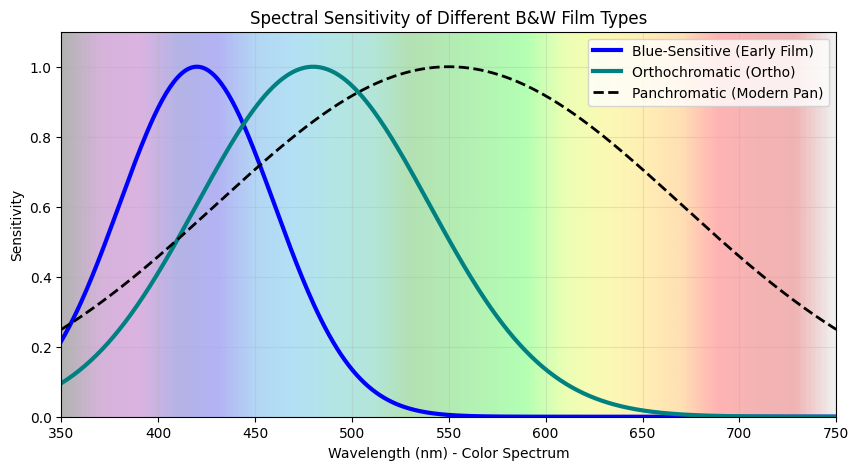

In [2]:
def simulate_spectral_sensitivity():
    wavelengths = np.linspace(350, 750, 400) # UV to Red (nanometers)
    
    # Sensitivity Curves (simplified models)
    blue_sens = np.exp(-((wavelengths - 420)**2) / (2 * 40**2))   # Peaks in blue
    ortho_sens = np.exp(-((wavelengths - 480)**2) / (2 * 60**2))  # Peaks in blue-green
    pan_sens = np.exp(-((wavelengths - 550)**2) / (2 * 120**2))  # Broad visibility
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(wavelengths, blue_sens, label='Blue-Sensitive (Early Film)', color='blue', linewidth=3)
    ax.plot(wavelengths, ortho_sens, label='Orthochromatic (Ortho)', color='teal', linewidth=3)
    ax.plot(wavelengths, pan_sens, label='Panchromatic (Modern Pan)', color='black', linestyle='--', linewidth=2)
    
    # Background rainbow
    extent = [350, 750, 0, 1.1]
    ax.imshow(np.linspace(0, 1, 400).reshape(1, -1), cmap='nipy_spectral', 
              alpha=0.3, extent=extent, aspect='auto')
    
    ax.set_title("Spectral Sensitivity of Different B&W Film Types")
    ax.set_xlabel("Wavelength (nm) - Color Spectrum")
    ax.set_ylabel("Sensitivity")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()

simulate_spectral_sensitivity()

## Iteration 3: The Filter Toolbox (Blocking Blue)

Now that we know film is naturally "over-sensitive" to blue and UV light, we can use filters to control it. 

**The Golden Rule of Filters:**
> A filter **lightens** objects of its own color and **darkens** its complementary (opposite) colors.

In B&W photography, we use warm filters to block blue light from reaching the film:

1. **Yellow (#8)**: The standard. It blocks UV and some blue. It makes white clouds "pop" against a slightly darker blue sky. It's the most "natural" looking filter.
2. **Orange (#15)**: Stronger. It darkens blue skies significantly and cuts through haze. It lightens skin tones (making them look smooth) but can make lips look pale.
3. **Red (#25)**: The most dramatic. It blocks almost all blue/green. Skies become nearly black (moonlight effect). It lightens red objects (like a red barn or red car) to almost white.

Let's simulate how a blue sky and white clouds change with these filters.

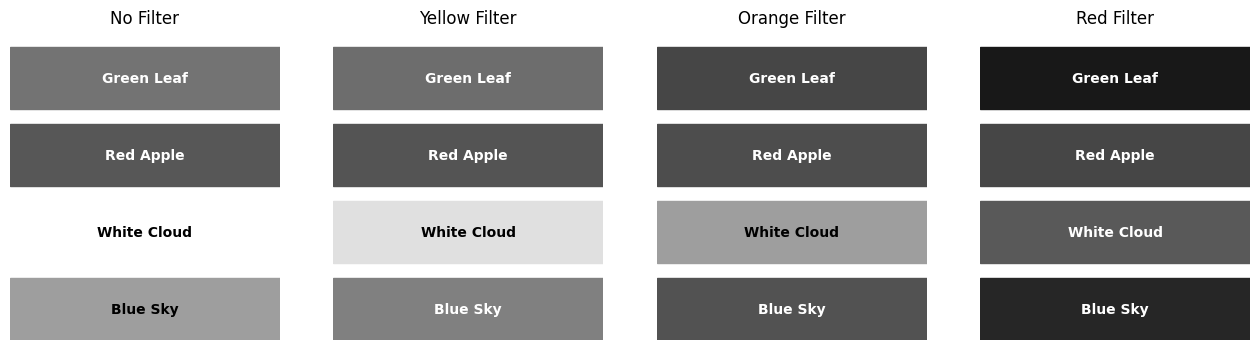

In [3]:
def simulate_filters():
    # Define colors: Sky Blue, White Cloud, Red Apple, Green Leaf
    subjects = {
        'Blue Sky': [0.4, 0.6, 1.0],
        'White Cloud': [1.0, 1.0, 1.0],
        'Red Apple': [0.9, 0.1, 0.1],
        'Green Leaf': [0.2, 0.7, 0.2]
    }
    
    # Filter Multipliers [R, G, B]
    # (Simplified: 1.0 means pass, 0.0 means block)
    filters = {
        'No Filter': [1.0, 1.0, 1.0],
        'Yellow Filter': [1.0, 1.0, 0.4],
        'Orange Filter': [1.0, 0.6, 0.1],
        'Red Filter': [1.0, 0.1, 0.0]
    }
    
    fig, axes = plt.subplots(1, len(filters), figsize=(16, 4))
    
    for ax, (f_name, f_rgb) in zip(axes, filters.items()):
        for i, (s_name, s_rgb) in enumerate(subjects.items()):
            # Apply filter (element-wise multiplication)
            filtered_color = [s_rgb[0]*f_rgb[0], s_rgb[1]*f_rgb[1], s_rgb[2]*f_rgb[2]]
            
            # Convert to Gray (Panchromatic sensitivity)
            gray = 0.3*filtered_color[0] + 0.5*filtered_color[1] + 0.2*filtered_color[2]
            
            # Draw patch
            ax.add_patch(plt.Rectangle((0, i), 1, 0.8, color=[gray]*3))
            ax.text(0.5, i+0.4, s_name, ha='center', va='center', 
                    color='black' if gray > 0.5 else 'white', fontweight='bold')
            
        ax.set_title(f_name)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, len(subjects))
        ax.axis('off')

    plt.show()

simulate_filters()

## Iteration 4: The Secret Weapon—The Green Filter

While Yellow and Red filters are the "rock stars" of B&W, the **Green filter** is the specialist's choice. 

**Why use a Green filter?**
1. **Foliage Separation**: In a forest, there are 50 shades of green. Without a filter, they often blend into a single muddy gray. A green filter lightens these greens, showing the texture of leaves.
2. **Portraiture**: It can make skin tones look more "rugged" or masculine by darkening red/ruddy spots (like freckles or blemishes) and lightening the green-blue undertones of the skin.
3. **Sky Contrast (Light)**: It still blocks some UV/Red, so it darkens a blue sky slightly, but not as much as a Red filter.

Let's add the Green filter to our simulator and see how it treats the "Green Leaf" compared to the Red filter.

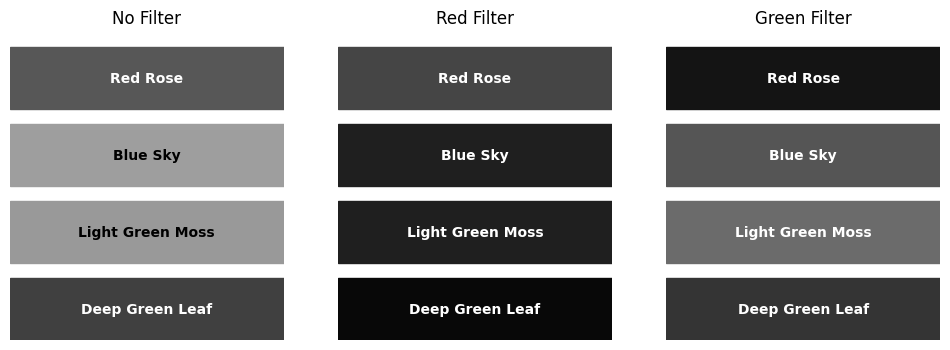

In [4]:
def simulate_green_filter():
    subjects = {
        'Deep Green Leaf': [0.1, 0.4, 0.1],
        'Light Green Moss': [0.4, 0.8, 0.4],
        'Blue Sky': [0.4, 0.6, 1.0],
        'Red Rose': [0.9, 0.1, 0.1]
    }
    
    filters = {
        'No Filter': [1.0, 1.0, 1.0],
        'Red Filter': [1.0, 0.0, 0.0],
        'Green Filter': [0.1, 1.0, 0.1]
    }
    
    fig, axes = plt.subplots(1, len(filters), figsize=(12, 4))
    
    for ax, (f_name, f_rgb) in zip(axes, filters.items()):
        for i, (s_name, s_rgb) in enumerate(subjects.items()):
            filtered = [s_rgb[j]*f_rgb[j] for j in range(3)]
            gray = 0.3*filtered[0] + 0.5*filtered[1] + 0.2*filtered[2]
            
            ax.add_patch(plt.Rectangle((0, i), 1, 0.8, color=[gray]*3))
            ax.text(0.5, i+0.4, s_name, ha='center', va='center', 
                    color='black' if gray > 0.5 else 'white', fontweight='bold')
            
        ax.set_title(f_name)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, len(subjects))
        ax.axis('off')

    plt.show()

simulate_green_filter()

## Iteration 5: Pre-visualization (Thinking in Gray)

How do master photographers know which filter to use? They use a technique called **Pre-visualization**.

### The Viewing Filter
Photographers often carry a "Viewing Filter"—a small piece of dark yellow or brown glass. When you look through it, the world's colors are suppressed, and you see mostly **Luminosity**. 

**Try this exercise:**
1. Look at a scene with your eyes (Color).
2. Squint your eyes slightly. This reduces color saturation and makes it easier to see shapes and values.
3. Ask yourself: "Are the red apple and the green leaf the same brightness?"
4. If yes, choose a Red filter to make the apple pop, or a Green filter to make the leaf pop.

### Summary Table
| Filter Color | Lightens... | Darkens... | Best For... |
| :--- | :--- | :--- | :--- |
| **Yellow** | Yellow, Green | Blue, Violet | Natural skies, clouds |
| **Orange** | Orange, Red | Blue, Green | Dramatic skies, haze cutting |
| **Red** | Red, Orange | Blue, Green | Black skies, white clouds, drama |
| **Green** | Green, Yellow | Red, Blue | Foliage, masculine portraits |

**Congratulations!** You now know how to "hack" the B&W world using the physics of light and the chemistry of film. Now go out and choose your filter!